In [1]:
import scanpy as sc
import treedata as td
import pycea as py
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Import utility functions made by Katie
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')

from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom

In [2]:
from Moslin.utility import add_gene_expression_to_tree, add_obs_to_tree, add_node_attrs_to_edges, flag_mixed_nodes

In [10]:
palette_template = [
    "#1D9E75",
    "#534AB7",
    "#D85A30",
    "#378ADD",
    "#D4537E",
    "#639922",
    "#BA7517",
    "#E24B4A",
    "#0F6E56",
    "#3C3489",
    "#993C1D",
    "#185FA5",
    "#993556",
    "#3B6D11",
    "#854F0B",
    "#A32D2D",
    "#5DCAA5",
    "#7F77DD",
    "#F09575",
    "#85B7EB",
    "#ED93B1",
    "#97C459",
    "#EF9F27",
    "#F09595",
    "#9FE1CB",
    "#AFA9EC",
    "#F5C4B3",
    "#B5D4F4",
    "#F4C0D1",
    "#C0DD97",
    "#FAC775",
    "#F7C1C1",
    "#04342C",
    "#26215C",
    "#4A1B0C",
    "#042C53",
    "#4B1528",
    "#173404",
    "#412402",
    "#501313",
    "#088268",
    "#443F9E",
    "#C04E24",
    "#2771C0",
    "#BF4570",
    "#4D7F18",
    "#A06512",
    "#C73F3E",
    "#1D5E82",
    "#7A2848",
    "#7B3F9E",
    "#2AABBA",
    "#E8860A",
    "#5C8526",
    "#C4396B",
    "#1A6B8A",
    "#9E5B1D",
    "#3D2D8A",
    "#B5991A",
    "#6B1A3A"
]

In [3]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/"
output_path_plot = base_path+plot_dir+"/JCF_FHF_SHF_analysis/"
adata_fname = "Processed_data/E7_5.h5td"

In [4]:
adata = td.read_h5td(output_path_data+"Processed_data/E8_0.h5td")
# adata = td.read_h5td(output_path_data+"Processed_data/E8_5.h5td")
adata.X = adata.layers["Raw_count"]

In [5]:
adata.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree,leiden_0.25,leiden_0.5,leiden_1.0,leiden_2.0
E8.0-R3-T1-CCCAATTTCATGGCAC-1,Forebrain,E8.0-R3-T1,E8.0-R3,E8.0,donor,18300.0,18.0,0.882353,0.440860,E8.0-R3-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R3-C1,0,0,0,0
E8.0-R3-T1-TGAACTTAGGTGCAAG-1,Forebrain,E8.0-R3-T1,E8.0-R3,E8.0,donor,11480.0,15.0,0.911765,0.437500,E8.0-R3-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R3-C1,0,0,4,4
E8.0-R3-T1-GGCATTCAGCCCTGTC-1,Forebrain,E8.0-R3-T1,E8.0-R3,E8.0,donor,16375.0,14.0,0.882353,0.473118,E8.0-R3-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R3-C1,0,0,4,10
E8.0-R3-T1-TAACCTAGTCATCACG-1,Forebrain,E8.0-R3-T1,E8.0-R3,E8.0,donor,12978.0,17.0,0.911765,0.416667,E8.0-R3-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R3-C1,0,0,4,10
E8.0-R3-T1-AGCTTAGTCACCACGG-1,Midbrain,E8.0-R3-T1,E8.0-R3,E8.0,donor,17592.0,18.0,0.882353,0.451613,E8.0-R3-C1,G2/M,Midbrain,Ectoderm,Neural ectoderm,E8.0-R3-C1,0,1,4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,28256.0,0.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,10,16,11,43
E8.0-R1-T1-TGGTCCTCACTCGGAA-1,Gut,E8.0-R1-T1,E8.0-R1,E8.0,donor,10322.0,17.0,0.735294,NaN,NaN,G2/M,Gut,Endoderm,Endoderm,NaN,1,3,5,32
E8.0-R1-T1-TGTAGCGCAATCGAGT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,16391.0,0.0,NaN,NaN,NaN,G2/M,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,10,16,11,43
E8.0-R1-T1-TGTCGATGTGCAATCT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,21732.0,1.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,10,16,11,43


In [6]:
set(adata.obs['cell_type']) #  'Juxtacardiac field' , 'First heart field', 'Second heart field', 'Anterior mesoderm' - 'anterior SHF' 

{'Allantoic endothelial progenitor',
 'Allantois',
 'Anterior mesoderm',
 'Axial progenitor',
 'Cranial neural crest',
 'Endothelial progenitor',
 'Extraembryonic mesoderm',
 'First heart field',
 'Forebrain',
 'Gut',
 'Hematoendothelial progenitor',
 'Hindbrain',
 'Intermediate mesoderm',
 'Juxtacardiac field',
 'Lateral plate mesoderm',
 'Midbrain',
 'Nascent mesoderm',
 'Nascent somite',
 'Notochord',
 'Parietal endoderm',
 'Presomitic mesoderm',
 'Primitive streak',
 'Primordial germ cell',
 'Second heart field',
 'Spinal cord',
 'Surface ectoderm',
 'Visceral endoderm'}

In [7]:
Cardiac_cell_types = {'Juxtacardiac field': 'Juxtacardiac field' , 
                      'First heart field': 'First heart field', 
                      'Second heart field': 'Second heart field',
                        'Anterior mesoderm' : 'anterior SHF' }

In [8]:
adata.obs["Cardiac_cell_types"] = adata.obs['cell_type'].map(Cardiac_cell_types)

In [9]:
adata.obs['Cardiac_cell_types'].unique()

array([nan, 'Second heart field', 'anterior SHF', 'Juxtacardiac field',
       'First heart field'], dtype=object)

In [10]:
plot_UMAP_custom(adata=adata,
        umap_coords_obsm="X_umap",
        color_by="Cardiac_cell_types",
        palette = "tab10",
        fig_title="All embryo per time point UMAP",
        output_path_plot=output_path_plot, 
        output_fname="E7_5_embryo_umap_by_Cardiac_Cell_Type.png"
)

In [11]:
adata.uns

{'leiden_0.25': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(0.25)}},
 'leiden_0.25_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a'],
       dtype=object),
 'leiden_0.5': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(0.5)}},
 'leiden_0.5_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d'],
       dtype=object),
 'leiden_1.0': {'params': {'n_iterations': np.int64(2),
   'random_state': np.int64(0),
   'resolution': np.float64(1.0)}},
 'leiden_1.0_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '

In [12]:
adata.uns["Cardiac_cell_types_colors"]

['#1f77b4', '#d62728', '#e377c2', '#17becf']

In [13]:
plt.rcParams["figure.figsize"] = (5, 20) # This changes the width, height of the plot

In [14]:
py.pp.add_depth(adata)

In [15]:
adata.uns["Cardiac_cell_types_colors"]

['#1f77b4', '#d62728', '#e377c2', '#17becf']

In [16]:
adata.obs["Cardiac_cell_types"] = adata.obs["Cardiac_cell_types"].astype("category")
print(adata.uns["Cardiac_cell_types_colors"])
print(len(adata.uns["Cardiac_cell_types_colors"]) == len(adata.obs["Cardiac_cell_types"].cat.categories))


['#1f77b4', '#d62728', '#e377c2', '#17becf']
True


<Axes: >

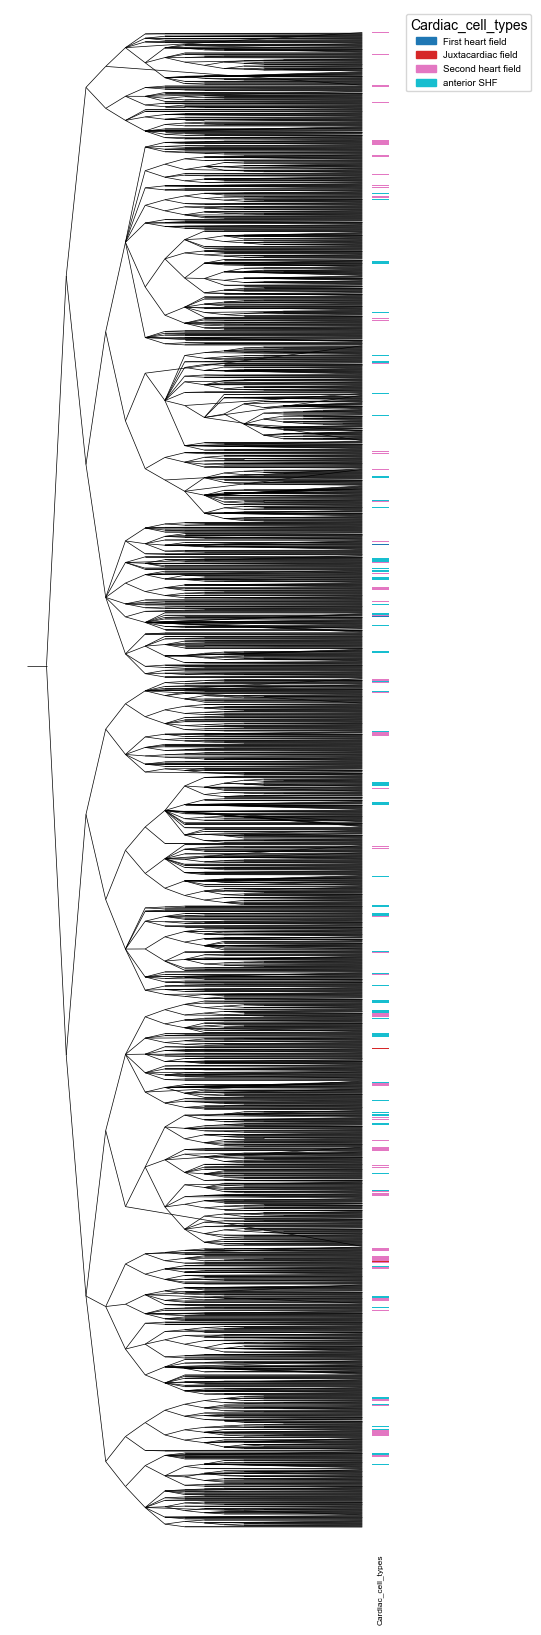

In [17]:
py.pl.branches(adata, depth_key="depth", angled_branches=True, extend_branches=True, tree="E8.0-R1-C1")
py.pl.annotation(adata, keys=["Cardiac_cell_types"], tree="E8.0-R1-C1")


In [18]:
import matplotlib.colors as mcolors
palette_template = mcolors.TABLEAU_COLORS

In [19]:
list(palette_template.values())

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

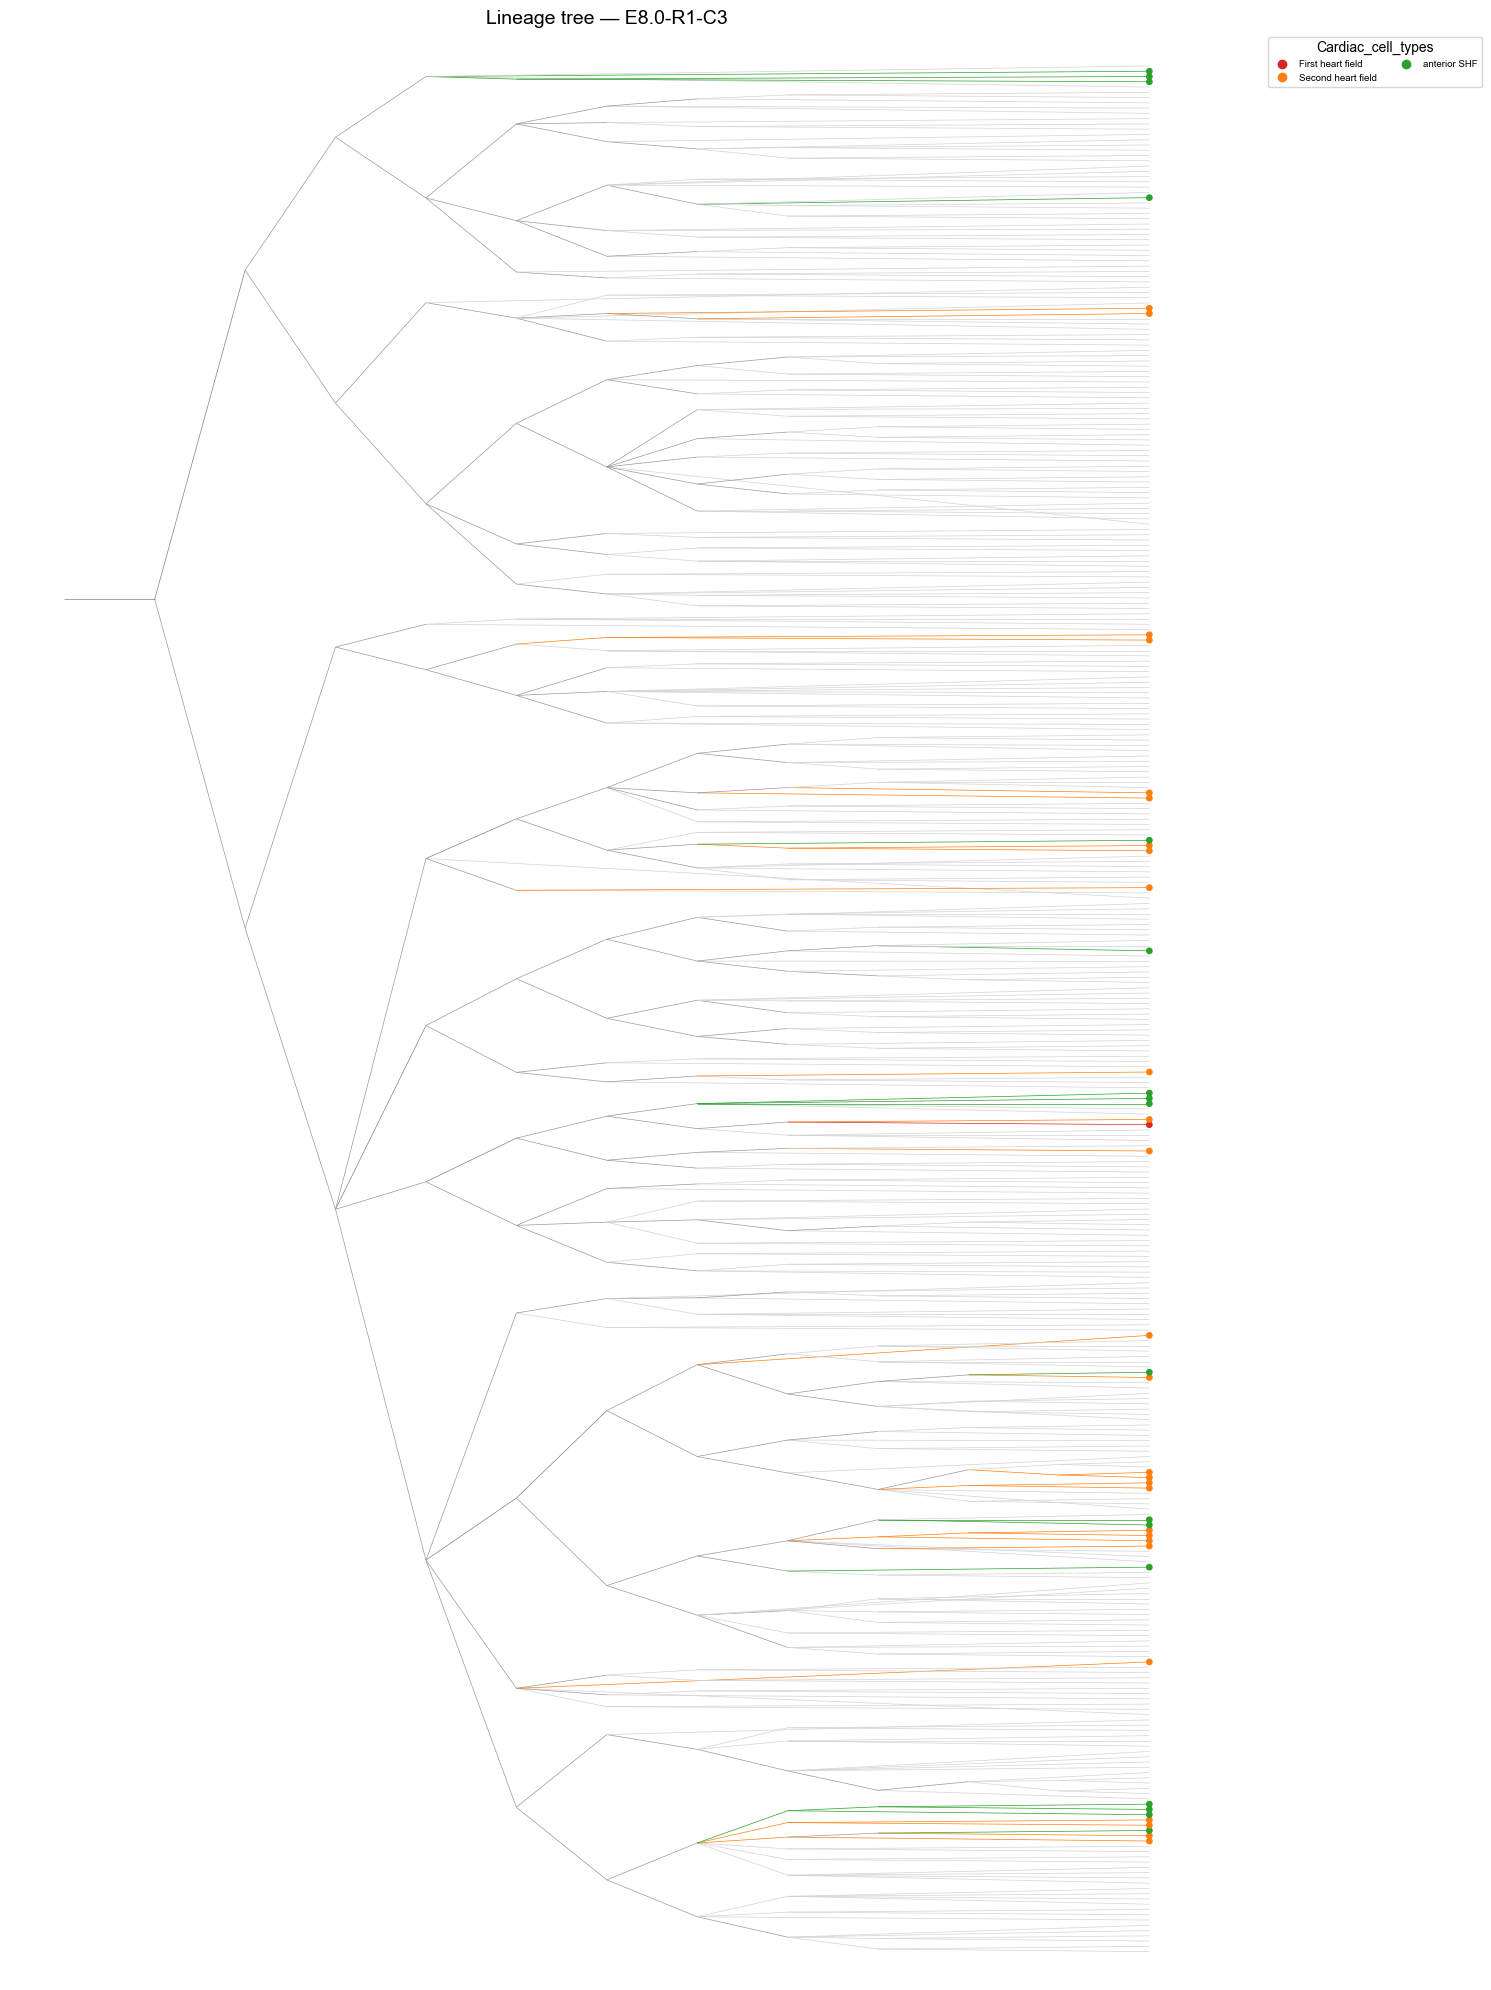

In [26]:
clone_key = "E8.0-R1-C3"
clone_tdata = adata[adata.obs["tree"] == clone_key].copy()
add_obs_to_tree(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys="Cardiac_cell_types", tree=clone_key, method="mode")
# override mixed internal nodes
flag_mixed_nodes(clone_tdata, clone_key, cell_type_key="Cardiac_cell_types")
# propagate to edges
add_node_attrs_to_edges(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])



# build palette: take your existing cell type colors and add mixed
import matplotlib.pyplot as plt

# get unique cell types present in this clone
cell_types = clone_tdata.obs["Cardiac_cell_types"].unique().tolist()
palette = dict(zip(cell_types, list(palette_template.values())[:len(cell_types)]))
palette['nan'] = 'gray'
palette["mixed"] = (0.6, 0.6, 0.6, 1.0)  # grey for mixed nodes

fig, ax = plt.subplots(figsize=(15, 20))
py.pl.branches(
    clone_tdata,
    depth_key="depth",
    color="Cardiac_cell_types",
    palette=palette,
    extend_branches=True,
    angled_branches=True,
    tree=clone_key,
    legend=False,
    ax=ax,
)
py.pl.nodes(
    clone_tdata,
    color="Cardiac_cell_types",
    palette=palette,
    nodes="leaves",
    size=15,
    legend=True,
    legend_kwargs={"ncols": 2, "bbox_to_anchor": (1.05, 1), "loc": "upper left"},
    tree=clone_key,
    ax=ax,
)
ax.set_title(f"Lineage tree — {clone_key}", fontsize=14)
plt.tight_layout()
#plt.show()
# plt.savefig(output_path_plot+"output.svg")

In [42]:

leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
len(leaf_order)

2444

In [24]:
lca_depths

array([[ 9,  8,  7, ...,  1,  1,  1],
       [ 8,  9,  7, ...,  1,  1,  1],
       [ 7,  7, 12, ...,  1,  1,  1],
       ...,
       [ 1,  1,  1, ...,  8,  7,  5],
       [ 1,  1,  1, ...,  7,  8,  5],
       [ 1,  1,  1, ...,  5,  5,  6]], shape=(2444, 2444))

/scratch/local/jobs/51458753/ipykernel_3133353/3190320156.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


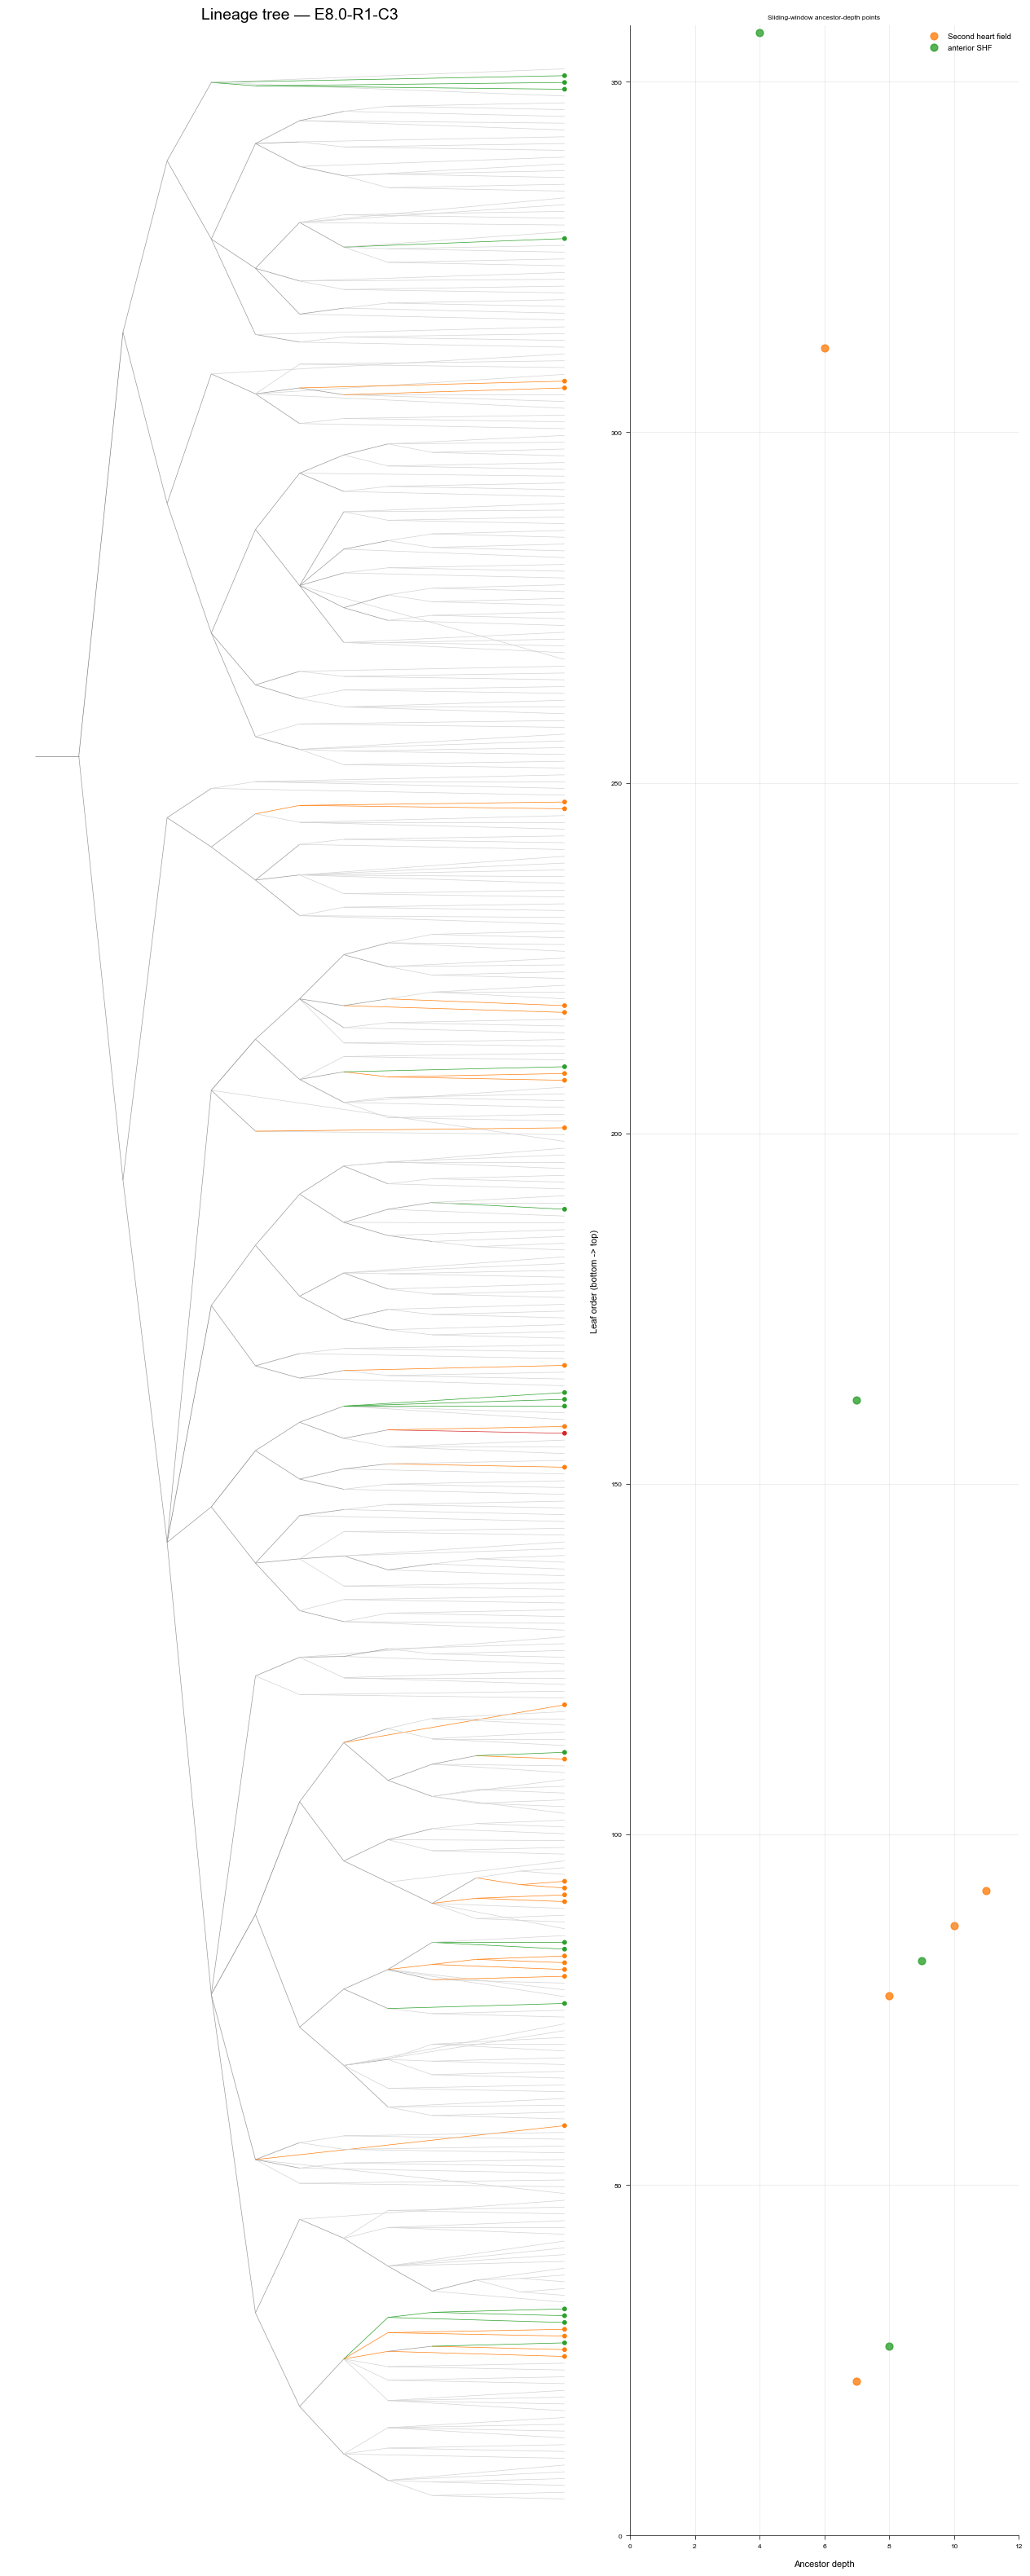

In [28]:
clone_key = "E8.0-R1-C3"
clone_tdata = adata[adata.obs["tree"] == clone_key].copy()
add_obs_to_tree(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys="Cardiac_cell_types", tree=clone_key, method="mode")
# override mixed internal nodes
flag_mixed_nodes(clone_tdata, clone_key, cell_type_key="Cardiac_cell_types")
# propagate to edges
add_node_attrs_to_edges(clone_tdata, keys=["Cardiac_cell_types", "germ_layer"])



# build palette: take your existing cell type colors and add mixed
import matplotlib.pyplot as plt

# get unique cell types present in this clone
cell_types = clone_tdata.obs["Cardiac_cell_types"].unique().tolist()
palette = dict(zip(cell_types, list(palette_template.values())[:len(cell_types)]))
palette['nan'] = 'gray'
palette["mixed"] = (0.6, 0.6, 0.6, 1.0)  # grey for mixed nodes

# Build an LCA distance matrix for the current clone tree
py.tl.tree_distance(clone_tdata, tree=clone_key, metric="lca", key_added="lca")
lca_depths = clone_tdata.obsp["lca_distances"]
if hasattr(lca_depths, "toarray"):
    lca_depths = lca_depths.toarray()

leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
cell_types = clone_tdata.obs.loc[leaf_order, "Cardiac_cell_types"].astype(str).to_numpy()

valid_types = [ct for ct in np.unique(cell_types) if ct not in {"nan", "None", "", "<NA>"}]

# Slide a 5-leaf window through the leaves from top to bottom.
# For each window and each cell type present in that window, compute the
# common-ancestor depth of those leaves and place a point shifted by that depth
# from the window's midpoint position.
points = []
for start in range(0, len(leaf_order), 5):
    window_leaves = leaf_order[start:start + 5]
    if len(window_leaves) < 2:
        continue

    middle_pos = start + 2
    if middle_pos >= len(leaf_order):
        middle_pos = len(leaf_order) - 1

    for ct in valid_types:
        ct_leaves = [leaf for leaf in window_leaves if clone_tdata.obs.loc[leaf, "Cardiac_cell_types"] == ct]
        if len(ct_leaves) < 2:
            continue

        ct_idx = [clone_tdata.obs_names.get_loc(leaf) for leaf in ct_leaves]
        sub = lca_depths[np.ix_(ct_idx, ct_idx)]
        tri = np.triu_indices(len(ct_idx), k=1)
        pair_depths = sub[tri]
        ancestor_depth = float(np.min(pair_depths)) if len(pair_depths) > 0 else 0.0

        points.append((ancestor_depth, middle_pos, ct))

# Create a tree panel and a right-side point panel
fig = plt.figure(figsize=(16, 40))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.08)
ax_tree = fig.add_subplot(gs[0])
ax_points = fig.add_subplot(gs[1])

py.pl.branches(
    clone_tdata,
    depth_key="depth",
    color="Cardiac_cell_types",
    palette=palette,
    extend_branches=True,
    angled_branches=True,
    tree=clone_key,
    legend=False,
    ax=ax_tree,
)
py.pl.nodes(
    clone_tdata,
    color="Cardiac_cell_types",
    palette=palette,
    nodes="leaves",
    size=10,
    legend=False,
    tree=clone_key,
    ax=ax_tree,
)
ax_tree.set_title(f"Lineage tree — {clone_key}", fontsize=14)

for ct in valid_types:
    subset = [p for p in points if p[2] == ct]
    if not subset:
        continue
    xs = [p[0] for p in subset]
    ys = [p[1] for p in subset]
    ax_points.scatter(xs, ys, color=palette.get(ct, "black"), s=40, alpha=0.8, label=ct)

x_max = max([p[0] for p in points], default=1.0)
ax_points.set_xlim(0, x_max + 1)
ax_points.set_ylim(0, len(leaf_order) - 1)
ax_points.set_xlabel("Ancestor depth")
ax_points.set_ylabel("Leaf order (bottom -> top)")
ax_points.set_title("Sliding-window ancestor-depth points")
ax_points.grid(alpha=0.2)
ax_points.legend(loc="best", frameon=False)

plt.tight_layout()
plt.savefig(output_path_plot + "E8_R1_C3_tree_with_celltype_points.svg", bbox_inches="tight")
plt.show()